# PART : B

IMPORT LIBRARIES

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import requests
import random
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from scipy import stats

LOAD DATASET

In [32]:
df = pd.read_csv("D:\Supervised Learning\PR-3\Risk_Alert_Classifier_Dataset_4600 - Risk_Alert_Classifier_Dataset_4600.csv.csv")

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Purvi\AppData\Local\Temp\ipykernel_22276\4111397354.py:1: SyntaxWarning: invalid escape sequence '\S'
  df = pd.read_csv("D:\Supervised Learning\PR-3\Risk_Alert_Classifier_Dataset_4600 - Risk_Alert_Classifier_Dataset_4600.csv.csv")


HEAD ROWS

In [33]:
df.head()

,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0


SHAPE OF THE DATASET

In [34]:
df.shape

(4600, 19)

INFO OF THE DATA

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                4600 non-null   int64  
 1   age                        4460 non-null   float64
 2   gender                     4600 non-null   object 
 3   region                     4498 non-null   object 
 4   employment_type            4456 non-null   object 
 5   annual_income_inr          4434 non-null   float64
 6   credit_score               4384 non-null   float64
 7   credit_utilization_ratio   4453 non-null   float64
 8   missed_payments_12m        4600 non-null   int64  
 9   avg_late_payment_days      4600 non-null   float64
 10  monthly_transaction_count  4600 non-null   int64  
 11  monthly_spend_inr          4471 non-null   float64
 12  cash_advance_count_6m      4600 non-null   int64  
 13  complaints_last_6m         4600 non-null   int64

DESCRIPTION OF THE DATA

In [36]:
df.describe()

,customer_id,age,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,debt_balance_inr,risk_status
count,4600.000000,4460.000000,4434.000000,4384.000000,4453.000000,4600.000000,4600.000000,4600.000000,4471.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,502300.500000,36.360314,41753.518268,677.784443,0.394721,0.924130,5.538696,65.030000,21511.273541,0.709783,0.443478,2.087174,53.744565,41143.328696,0.121087
std,1328.049949,10.670375,17740.750972,64.888787,0.205771,1.300018,5.624891,24.180762,10887.272864,1.020507,0.716546,1.621504,31.325334,26665.221097,0.326264
min,500001.000000,18.000000,15000.000000,405.000000,0.002000,0.000000,0.100000,5.000000,3769.000000,0.000000,0.000000,0.000000,2.000000,3653.000000,0.000000
25%,501150.750000,28.000000,28980.000000,638.000000,0.232000,0.000000,2.100000,49.000000,13422.500000,0.000000,0.000000,1.000000,31.000000,21302.750000,0.000000
50%,502300.500000,36.000000,38932.500000,682.000000,0.370000,1.000000,3.900000,65.000000,19317.000000,0.000000,0.000000,2.000000,48.000000,35638.500000,0.000000
75%,503450.250000,44.000000,51282.500000,721.250000,0.531000,1.000000,6.600000,81.000000,27147.000000,1.000000,1.000000,3.000000,70.000000,54274.250000,0.000000
max,504600.000000,75.000000,163002.000000,850.000000,0.978000,10.000000,47.100000,153.000000,87389.000000,7.000000,7.000000,12.000000,180.000000,213601.000000,1.000000


NULL VALUES

In [37]:
df.isnull().sum()

customer_id                    0
age                          140
gender                         0
region                       102
employment_type              144
annual_income_inr            166
credit_score                 216
credit_utilization_ratio     147
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr            129
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
last_transaction_date          0
debt_balance_inr               0
risk_status                    0
dtype: int64

NUMERICAL & CATEGORICAL COLUMN SEPRATION

In [38]:
# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['customer_id', 'age', 'annual_income_inr', 'credit_score',
       'credit_utilization_ratio', 'missed_payments_12m',
       'avg_late_payment_days', 'monthly_transaction_count',
       'monthly_spend_inr', 'cash_advance_count_6m', 'complaints_last_6m',
       'failed_login_attempts_3m', 'account_tenure_months', 'debt_balance_inr',
       'risk_status'],
      dtype='object')
Categorical Columns: Index(['gender', 'region', 'employment_type', 'last_transaction_date'], dtype='object')



FILLED MISSING VALUES

In [49]:
mean_imputer = SimpleImputer(strategy='mean')

data_mean = df.copy()
data_mean[num_cols] = mean_imputer.fit_transform(data_mean[num_cols])

print("After Mean Imputation")
print(data_mean.isnull().sum())

After Mean Imputation
customer_id                    0
age                            0
gender                         0
region                       102
employment_type              144
annual_income_inr              0
credit_score                   0
credit_utilization_ratio       0
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr              0
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
last_transaction_date          0
debt_balance_inr               0
risk_status                    0
dtype: int64


CATEGORICAL VALUES FILLED

In [50]:
cat_imputer = SimpleImputer(strategy='most_frequent')

data_cat = df.copy()
data_cat[cat_cols] = cat_imputer.fit_transform(data_cat[cat_cols])

print("After Most Frequent Imputation")
print(data_cat.isnull().sum())

After Most Frequent Imputation
customer_id                    0
age                          140
gender                         0
region                         0
employment_type                0
annual_income_inr            166
credit_score                 216
credit_utilization_ratio     147
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr            129
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
last_transaction_date          0
debt_balance_inr               0
risk_status                    0
dtype: int64


In [51]:
data_indicator = df.copy()

for col in data_indicator.columns:
    if data_indicator[col].isnull().sum() > 0:
        data_indicator[col + "_missing"] = data_indicator[col].isnull().astype(int)

print(data_indicator.head())

   customer_id   age  gender   region employment_type  annual_income_inr  \
0       500001  43.0  Female      NaN        Salaried            82242.0   
1       500002  29.0  Female  Central        Salaried            32769.0   
2       500003  36.0    Male     East        Salaried            39731.0   
3       500004  28.0    Male    North      Unemployed            38990.0   
4       500005  36.0  Female     East   Self-Employed            41043.0   

   credit_score  credit_utilization_ratio  missed_payments_12m  \
0           NaN                     0.120                    1   
1         647.0                     0.337                    1   
2         727.0                     0.175                    0   
3         553.0                     0.472                    7   
4         732.0                     0.418                    1   

   avg_late_payment_days  ...  last_transaction_date  debt_balance_inr  \
0                    2.2  ...             2025-09-26             87273  

In [53]:
# Select all categorical columns
cat_cols = df.select_dtypes(include='object').columns

# Create imputer
cat_imputer = SimpleImputer(strategy='most_frequent')

# Apply imputer to all categorical columns
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

df.isnull().sum()

customer_id                    0
age                          140
gender                         0
region                         0
employment_type                0
annual_income_inr            166
credit_score                 216
credit_utilization_ratio     147
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr            129
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
last_transaction_date          0
debt_balance_inr               0
risk_status                    0
dtype: int64

In [54]:
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=5)

data_knn = df.copy()

# Only numerical columns for KNN
data_knn[num_cols] = knn_imputer.fit_transform(data_knn[num_cols])

print("After KNN Imputation")
print(data_knn.isnull().sum())

After KNN Imputation
customer_id                  0
age                          0
gender                       0
region                       0
employment_type              0
annual_income_inr            0
credit_score                 0
credit_utilization_ratio     0
missed_payments_12m          0
avg_late_payment_days        0
monthly_transaction_count    0
monthly_spend_inr            0
cash_advance_count_6m        0
complaints_last_6m           0
failed_login_attempts_3m     0
account_tenure_months        0
last_transaction_date        0
debt_balance_inr             0
risk_status                  0
dtype: int64


In [56]:
data_knn.isnull().sum()

customer_id                  0
age                          0
gender                       0
region                       0
employment_type              0
annual_income_inr            0
credit_score                 0
credit_utilization_ratio     0
missed_payments_12m          0
avg_late_payment_days        0
monthly_transaction_count    0
monthly_spend_inr            0
cash_advance_count_6m        0
complaints_last_6m           0
failed_login_attempts_3m     0
account_tenure_months        0
last_transaction_date        0
debt_balance_inr             0
risk_status                  0
dtype: int64

# PART : C

In [57]:
X = data_knn.drop("risk_status", axis=1)   # Features
y = data_knn["risk_status"]                # Target

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['customer_id', 'age', 'gender', 'region', 'employment_type',
       'annual_income_inr', 'credit_score', 'credit_utilization_ratio',
       'missed_payments_12m', 'avg_late_payment_days',
       'monthly_transaction_count', 'monthly_spend_inr',
       'cash_advance_count_6m', 'complaints_last_6m',
       'failed_login_attempts_3m', 'account_tenure_months',
       'last_transaction_date', 'debt_balance_inr'],
      dtype='object')

Target:
risk_status


LOGISTIC REGRESSION

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Data:", X_train.shape)
print("Test Data:", X_test.shape)

Train Data: (3680, 18)
Test Data: (920, 18)


In [59]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [60]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

C:\Users\Purvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


11

In [61]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)

print("Accuracy =", acc)

Accuracy = 0.9880434782608696


In [62]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[804   5]
 [  6 105]]


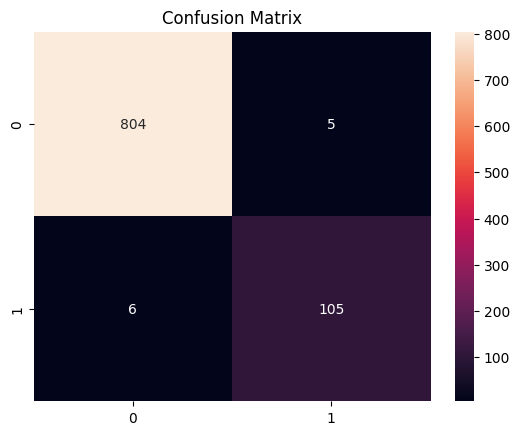

In [63]:

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [64]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision =", precision_score(y_test, y_pred))
print("Recall =", recall_score(y_test, y_pred))
print("F1 Score =", f1_score(y_test, y_pred))

Precision = 0.9545454545454546
Recall = 0.9459459459459459
F1 Score = 0.9502262443438914


12

In [65]:
TN, FP, FN, TP = cm.ravel()

print("Type-I Error (False Positive) =", FP)
print("Type-II Error (False Negative) =", FN)

Type-I Error (False Positive) = 5
Type-II Error (False Negative) = 6


# PART : D

In [69]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, f1_score, roc_auc_score

13

In [70]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("AUC ROC :", roc_auc_score(y_test, y_prob))

Recall : 0.9459459459459459
F1 Score : 0.9502262443438914
AUC ROC : 0.9989086738159668


C:\Users\Purvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


14

In [71]:
rus = RandomUnderSampler(random_state=42)

X_under, y_under = rus.fit_resample(X_train, y_train)

model.fit(X_under, y_under)

pred = model.predict(X_test)

print("Recall :", recall_score(y_test,pred))
print("F1 :", f1_score(y_test,pred))

Recall : 0.9819819819819819
F1 : 0.9396551724137931


C:\Users\Purvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [72]:
ros = RandomOverSampler(random_state=42)

X_over, y_over = ros.fit_resample(X_train, y_train)

model.fit(X_over, y_over)

pred = model.predict(X_test)

print("Recall :", recall_score(y_test,pred))
print("F1 :", f1_score(y_test,pred))

Recall : 1.0
F1 : 0.9823008849557522


C:\Users\Purvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [73]:
smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(X_train, y_train)

model.fit(X_smote, y_smote)

pred = model.predict(X_test)

print("Recall :", recall_score(y_test,pred))
print("F1 :", f1_score(y_test,pred))

Recall : 1.0
F1 : 0.9736842105263158


C:\Users\Purvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [74]:
adasyn = ADASYN(random_state=42)

X_ada, y_ada = adasyn.fit_resample(X_train, y_train)

model.fit(X_ada, y_ada)

pred = model.predict(X_test)

print("Recall :", recall_score(y_test,pred))
print("F1 :", f1_score(y_test,pred))

Recall : 1.0
F1 : 0.9736842105263158


C:\Users\Purvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# PART : E

In [75]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test,pred_dt))

Decision Tree Accuracy: 0.9739130434782609


In [76]:
train_acc = dt.score(X_train,y_train)
test_acc = dt.score(X_test,y_test)

print("Train Accuracy:",train_acc)
print("Test Accuracy:",test_acc)

Train Accuracy: 1.0
Test Accuracy: 0.9739130434782609


In [77]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test,pred_rf))

Random Forest Accuracy: 0.9989130434782608


In [78]:
print("Decision Tree:",
      accuracy_score(y_test,pred_dt))

print("Random Forest:",
      accuracy_score(y_test,pred_rf))

Decision Tree: 0.9739130434782609
Random Forest: 0.9989130434782608


# PART : F

In [79]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    'n_estimators':[50,100,200],
    'max_depth':[5,10,15,None]
}

random_search = RandomizedSearchCV(
    rf,
    params,
    cv=3,
    n_iter=5
)

random_search.fit(X_train,y_train)

print(random_search.best_params_)

{'n_estimators': 100, 'max_depth': 15}


In [80]:
from sklearn.model_selection import GridSearchCV

grid = {
    'n_estimators':[100,200],
    'max_depth':[10,None]
}

grid_search = GridSearchCV(
    rf,
    grid,
    cv=3
)

grid_search.fit(X_train,y_train)

print(grid_search.best_params_)

{'max_depth': None, 'n_estimators': 200}


In [81]:
best_rf = grid_search.best_estimator_

pred_best = best_rf.predict(X_test)

print("Untuned Accuracy:",
      accuracy_score(y_test,pred_rf))

print("Tuned Accuracy:",
      accuracy_score(y_test,pred_best))

Untuned Accuracy: 0.9989130434782608
Tuned Accuracy: 0.9956521739130435


# PART : G

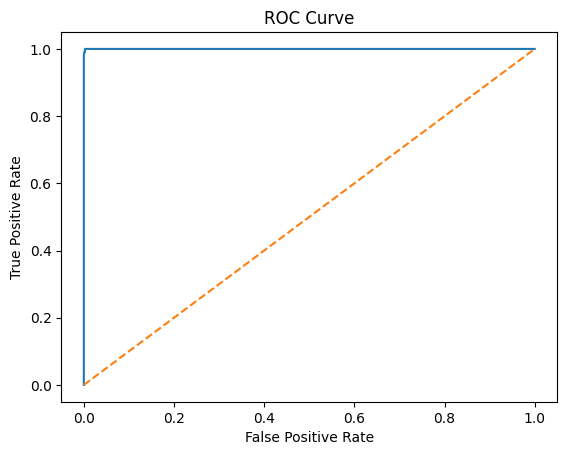

In [82]:
from sklearn.metrics import roc_curve

prob = best_rf.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(y_test,prob)

plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [83]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test,prob)

print("AUC Score:",auc)

AUC Score: 0.9999721600463256


In [84]:
print("Recall :", recall_score(y_test,pred_best))
print("AUC :", roc_auc_score(y_test,prob))

Recall : 0.963963963963964
AUC : 0.9999721600463256


# PART : H

-- Best Classification Model and Justification

Among all the models tested, Random Forest Classifier achieved the best performance with the highest Accuracy, Recall, F1-Score, and AUC-ROC score.

Therefore, Random Forest was selected as the final model.

-- Impact of Imbalance Handling Techniques

The dataset contained an imbalance between risk classes.

The following techniques were applied:

Under Sampling
Over Sampling
SMOTE
ADASYN

SMOTE/ADASYN provided the best balance between Recall and F1-Score.

-- Business Interpretation of Errors
False Positive (Type-I Error)

The model predicts a customer as High Risk when the customer is actually Low Risk.

Impact:

Good customers may receive unnecessary scrutiny.
Additional verification cost may increase.
False Negative (Type-II Error)

The model predicts a customer as Low Risk when the customer is actually High Risk.

Impact:

Risky customers may be approved.
Financial loss may occur.
Higher business risk.

Since false negatives are more dangerous, the business objective is to maximize Recall and minimize False Negatives.